In [1]:
# Imports
import math
import sys, os
import numpy as np
import pandas as pd
import seaborn as sns
import duckdb
import matplotlib.pyplot as plt

In [2]:
#Modulos com funções para tratamento de dados
sys.path.append(os.path.abspath(os.path.join('modulos')))
from modulo01 import *
from modulo02 import *
from modulo03 import *

In [3]:
pd.set_option('display.max_columns', 100)

In [4]:
df_original = pd.read_csv("Traffic_Crashes_-_Crashes.csv")

In [5]:
df_original.head(10)

,CRASH_RECORD_ID,RD_NO,CRASH_DATE_EST_I,CRASH_DATE,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,LANE_CNT,ALIGNMENT,ROADWAY_SURFACE_COND,ROAD_DEFECT,REPORT_TYPE,CRASH_TYPE,INTERSECTION_RELATED_I,NOT_RIGHT_OF_WAY_I,HIT_AND_RUN_I,DAMAGE,DATE_POLICE_NOTIFIED,PRIM_CONTRIBUTORY_CAUSE,SEC_CONTRIBUTORY_CAUSE,STREET_NO,STREET_DIRECTION,STREET_NAME,BEAT_OF_OCCURRENCE,PHOTOS_TAKEN_I,STATEMENTS_TAKEN_I,DOORING_I,WORK_ZONE_I,WORK_ZONE_TYPE,WORKERS_PRESENT_I,NUM_UNITS,MOST_SEVERE_INJURY,INJURIES_TOTAL,INJURIES_FATAL,INJURIES_INCAPACITATING,INJURIES_NON_INCAPACITATING,INJURIES_REPORTED_NOT_EVIDENT,INJURIES_NO_INDICATION,INJURIES_UNKNOWN,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,LATITUDE,LONGITUDE,LOCATION
0,04513a0efcfb7ab3bd29b43dc62b47a8c28acbd2422468...,JF221993,NaN,04/27/2022 02:00:00 PM,30,STOP SIGN/FLASHER,FUNCTIONING PROPERLY,CLOUDY/OVERCAST,DAYLIGHT,REAR END,PARKING LOT,NaN,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,NO INJURY / DRIVE AWAY,NaN,NaN,NaN,$500 OR LESS,04/27/2022 02:15:00 PM,FOLLOWING TOO CLOSELY,FOLLOWING TOO CLOSELY,1,W,PARKING LOT E ST,1654.0,NaN,NaN,NaN,NaN,NaN,NaN,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0.0,14,4,4,NaN,NaN,NaN
1,0b4fad8ea42bbbddfe40672be64bf098b5230e1d7a8e83...,JD347173,NaN,08/27/2020 02:48:00 PM,30,NO CONTROLS,NO CONTROLS,CLEAR,DAYLIGHT,REAR END,DIVIDED - W/MEDIAN (NOT RAISED),NaN,STRAIGHT AND LEVEL,WET,UNKNOWN,NaN,INJURY AND / OR TOW DUE TO CRASH,NaN,NaN,Y,"OVER $1,500",08/27/2020 02:49:00 PM,UNABLE TO DETERMINE,UNABLE TO DETERMINE,2605,N,PULASKI RD,2524.0,NaN,NaN,NaN,NaN,NaN,NaN,2,"REPORTED, NOT EVIDENT",1.0,0.0,0.0,0.0,1.0,1.0,0.0,14,5,8,41.928341,-87.726734,POINT (-87.726734064044 41.928340900019)
2,85d7170ddb037d53299eda4501559f337f954b97733a88...,JF269498,NaN,06/03/2022 08:51:00 PM,15,UNKNOWN,UNKNOWN,UNKNOWN,"DARKNESS, LIGHTED ROAD",PARKED MOTOR VEHICLE,PARKING LOT,NaN,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NOT ON SCENE (DESK REPORT),NO INJURY / DRIVE AWAY,NaN,NaN,NaN,"$501 - $1,500",06/06/2022 10:45:00 AM,UNABLE TO DETERMINE,UNABLE TO DETERMINE,804,W,OHARE ST,1654.0,NaN,NaN,NaN,NaN,NaN,NaN,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,1.0,0.0,20,6,6,NaN,NaN,NaN
3,2de6ce7f5a08a154f076aaf4210bb896f44261d99aa6a4...,JF228502,NaN,05/03/2022 10:00:00 AM,15,NO CONTROLS,NO CONTROLS,RAIN,DAYLIGHT,SIDESWIPE SAME DIRECTION,ONE-WAY,NaN,STRAIGHT AND LEVEL,WET,NO DEFECTS,ON SCENE,NO INJURY / DRIVE AWAY,NaN,NaN,NaN,"OVER $1,500",05/03/2022 10:02:00 AM,FAILING TO YIELD RIGHT-OF-WAY,NOT APPLICABLE,3,W,TERMINAL ST,1653.0,NaN,NaN,NaN,NaN,NaN,NaN,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0.0,10,3,5,NaN,NaN,NaN
4,3f0a6d0f013ac8efb04d8bf4694478da52658d15126d9c...,JF244095,NaN,05/16/2022 08:29:00 AM,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,DAYLIGHT,REAR END,NOT DIVIDED,NaN,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NOT ON SCENE (DESK REPORT),NO INJURY / DRIVE AWAY,NaN,NaN,NaN,"$501 - $1,500",05/16/2022 10:00:00 AM,IMPROPER BACKING,UNABLE TO DETERMINE,8147,S,VINCENNES AVE,622.0,NaN,NaN,NaN,NaN,NaN,NaN,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0.0,8,2,5,41.745792,-87.635370,POINT (-87.63536999702 41.745792169991)
5,3dae1e1c953f62b1fe59d6d8157f687af04e46b6a0414b...,JF228431,NaN,05/03/2022 08:50:00 AM,25,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,RAIN,DAYLIGHT,TURNING,NOT DIVIDED,NaN,STRAIGHT AND LEVEL,WET,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,Y,NaN,Y,"OVER $1,500",05/03/2022 08:51:00 AM,FAILING TO YIELD RIGHT-OF-WAY,DRIVING SKILLS/KNOWLEDGE/EXPERIENCE,5000,W,FOSTER AVE,1623.0,NaN,NaN,NaN,NaN,NaN,NaN,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0.0,8,3,5,41.975384,-87.752959,POINT (-87.752958923026 41.975383528015)
6,3eac1fd4cd9da628ec29f8c316dc87fc2245b7f092e310...,JF229369,NaN,05/03/2022 10:00:00 PM,20,NO CONTROLS,NO CONTROLS,RAIN,"DARKNESS, LIGHTED ROAD",ANGLE,ONE-WAY,NaN,STRAIGHT AND LEVEL,WET,NO DEFECTS,ON SCENE,NO INJURY / DRIVE AWAY,NaN,NaN,NaN,"OVER $1,500",05/03/2022 10:03:00 PM,UNABLE TO DETERMINE,UN

In [6]:
df_original.shape

(632914, 49)

In [7]:
df_clean = df_original.copy()

In [8]:
#Função que mostra se há dados ausentes
func_calc_percentual_valores_ausentes(df_clean)

O dataset tem 20.5 % de valores ausentes.


In [9]:
#Função que mostra dados ausentes por coluna
df_missing = func_calc_percentual_valores_ausentes_coluna(df_clean)
df_missing

O dataset tem 49 colunas.
Encontrado: 27 colunas que têm valores ausentes.


,Valores Ausentes,% de Valores Ausentes,Dtype
WORKERS_PRESENT_I,631957,99.85,object
DOORING_I,630943,99.69,object
WORK_ZONE_TYPE,629948,99.53,object
WORK_ZONE_I,629137,99.40,object
PHOTOS_TAKEN_I,625135,98.77,object
STATEMENTS_TAKEN_I,619977,97.96,object
NOT_RIGHT_OF_WAY_I,603094,95.29,object
CRASH_DATE_EST_I,584930,92.42,object
INTERSECTION_RELATED_I,488182,77.13,object
HIT_AND_RUN_I,438395,69.27,object


In [10]:
#Procedimento para remover colunas que possuam 30% ou mais de dados ausentes
colunas_para_remover = df_missing[df_missing['% de Valores Ausentes'] >= 30.00].index.tolist()

In [11]:
# Colunas que serão removidas
colunas_para_remover

['WORKERS_PRESENT_I',
 'DOORING_I',
 'WORK_ZONE_TYPE',
 'WORK_ZONE_I',
 'PHOTOS_TAKEN_I',
 'STATEMENTS_TAKEN_I',
 'NOT_RIGHT_OF_WAY_I',
 'CRASH_DATE_EST_I',
 'INTERSECTION_RELATED_I',
 'HIT_AND_RUN_I',
 'LANE_CNT']

In [12]:
df_clean = df_clean.drop(colunas_para_remover, axis = 1)

In [13]:
df_clean.shape

(632914, 38)

In [14]:
func_calc_percentual_valores_ausentes(df_clean)

O dataset tem 0.18 % de valores ausentes.


In [15]:
df_clean['REPORT_TYPE'].value_counts(normalize=True)

REPORT_TYPE
NOT ON SCENE (DESK REPORT)    0.570719
ON SCENE                      0.428891
AMENDED                       0.000389
Name: proportion, dtype: float64

In [16]:
#Decidi aplicar o valor moda para tratar dados ausentes, já que tem apenas dois valores, não impactará os dados
df_clean['REPORT_TYPE'].fillna('NOT ON SCENE (DESK REPORT)', inplace=True)
df_clean['REPORT_TYPE'].value_counts(normalize=True)

C:\Users\vilia\AppData\Local\Temp\ipykernel_13360\2197072687.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['REPORT_TYPE'].fillna('NOT ON SCENE (DESK REPORT)', inplace=True)


REPORT_TYPE
NOT ON SCENE (DESK REPORT)    0.582021
ON SCENE                      0.417600
AMENDED                       0.000379
Name: proportion, dtype: float64

In [17]:
df_clean['REPORT_TYPE'].isnull().sum()

np.int64(0)

In [18]:
#Restantes de colunas tinha menos de 1% de dados ausentes. Por se tratar de um grande volume de dados, optei por apagar linhas
df_clean.dropna(inplace=True)

In [19]:
func_calc_percentual_valores_ausentes(df_clean)

O dataset tem 0.0 % de valores ausentes.


In [20]:
#Removendo valores duplicados no ID
df_clean['CRASH_RECORD_ID'].drop_duplicates(inplace=True)
df_clean.shape

(623783, 38)

In [21]:
#Após remover duplicados, apagar a coluna de ID pois não tem utilidade para análise
drop_columns(df_clean, ['CRASH_RECORD_ID'])

1 coluna foi descartada.


In [22]:
df_clean.shape

(623783, 37)

In [23]:
df_clean.head(50)

,RD_NO,CRASH_DATE,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,ALIGNMENT,ROADWAY_SURFACE_COND,ROAD_DEFECT,REPORT_TYPE,CRASH_TYPE,DAMAGE,DATE_POLICE_NOTIFIED,PRIM_CONTRIBUTORY_CAUSE,SEC_CONTRIBUTORY_CAUSE,STREET_NO,STREET_DIRECTION,STREET_NAME,BEAT_OF_OCCURRENCE,NUM_UNITS,MOST_SEVERE_INJURY,INJURIES_TOTAL,INJURIES_FATAL,INJURIES_INCAPACITATING,INJURIES_NON_INCAPACITATING,INJURIES_REPORTED_NOT_EVIDENT,INJURIES_NO_INDICATION,INJURIES_UNKNOWN,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,LATITUDE,LONGITUDE,LOCATION
1,JD347173,08/27/2020 02:48:00 PM,30,NO CONTROLS,NO CONTROLS,CLEAR,DAYLIGHT,REAR END,DIVIDED - W/MEDIAN (NOT RAISED),STRAIGHT AND LEVEL,WET,UNKNOWN,NOT ON SCENE (DESK REPORT),INJURY AND / OR TOW DUE TO CRASH,"OVER $1,500",08/27/2020 02:49:00 PM,UNABLE TO DETERMINE,UNABLE TO DETERMINE,2605,N,PULASKI RD,2524.0,2,"REPORTED, NOT EVIDENT",1.0,0.0,0.0,0.0,1.0,1.0,0.0,14,5,8,41.928341,-87.726734,POINT (-87.726734064044 41.928340900019)
4,JF244095,05/16/2022 08:29:00 AM,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,DAYLIGHT,REAR END,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NOT ON SCENE (DESK REPORT),NO INJURY / DRIVE AWAY,"$501 - $1,500",05/16/2022 10:00:00 AM,IMPROPER BACKING,UNABLE TO DETERMINE,8147,S,VINCENNES AVE,622.0,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0.0,8,2,5,41.745792,-87.635370,POINT (-87.63536999702 41.745792169991)
5,JF228431,05/03/2022 08:50:00 AM,25,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,RAIN,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,WET,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,"OVER $1,500",05/03/2022 08:51:00 AM,FAILING TO YIELD RIGHT-OF-WAY,DRIVING SKILLS/KNOWLEDGE/EXPERIENCE,5000,W,FOSTER AVE,1623.0,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0.0,8,3,5,41.975384,-87.752959,POINT (-87.752958923026 41.975383528015)
9,JF244267,05/16/2022 10:31:00 AM,30,NO CONTROLS,NO CONTROLS,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,"OVER $1,500",05/16/2022 10:31:00 AM,FAILING TO YIELD RIGHT-OF-WAY,NOT APPLICABLE,2305,W,47TH ST,931.0,2,NONINCAPACITATING INJURY,1.0,0.0,0.0,1.0,0.0,1.0,0.0,10,2,5,41.808321,-87.682241,POINT (-87.68224077098 41.808320646996)
11,JF214106,04/20/2022 05:45:00 PM,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NOT ON SCENE (DESK REPORT),NO INJURY / DRIVE AWAY,"OVER $1,500",04/20/2022 06:42:00 PM,DISREGARDING TRAFFIC SIGNALS,FAILING TO REDUCE SPEED TO AVOID CRASH,1859,N,ELSTON AVE,1433.0,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0.0,17,4,4,41.916381,-87.666190,POINT (-87.666189730021 41.916381427046)
13,JF258833,05/28/2022 01:27:00 PM,25,NO CONTROLS,NO CONTROLS,CLEAR,DAYLIGHT,PARKED MOTOR VEHICLE,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,UNKNOWN,ON SCENE,NO INJURY / DRIVE AWAY,"$501 - $1,500",05/28/2022 01:27:00 PM,IMPROPER OVERTAKING/PASSING,UNABLE TO DETERMINE,1411,W,CUYLER AVE,1912.0,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,1.0,0.0,13,7,5,41.955159,-87.664764,POINT (-87.664764329976 41.955158726028)
17,JF244061,05/16/2022 09:00:00 AM,25,NO CONTROLS,NO CONTROLS,CLEAR,DAYLIGHT,PARKED MOTOR VEHICLE,ONE-WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,NO INJURY / DRIVE AWAY,"OVER $1,500",05/16/2022 09:33:00 AM,UNABLE TO DETERMINE,UNABLE TO DETERMINE,2406,S,AVERS AVE,1013.0,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9,2,5,41.847703,-87.721132,POINT (-87.721131719023 41.847703471954)
21,JF229088,05/03/2022 10:00:00 AM,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,RAIN,DAYLIGHT,REAR END,NOT DIVIDED,STRAIGHT AND LEVEL,WET,NO DEFECTS,NOT ON SCENE (DESK REPORT),NO INJURY / DRIVE AWAY,"OVER $1,500",05/03/2022 05:40:00 PM,FOLLOWING TOO CLOSELY,FOLLOWING TOO CLOSELY,4701,S,KEDVALE AVE,815.0,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0.0,10,3,5,41.807737,-87.727106,POINT (-87.727106124019 41.807737431999)
22,JF265341,06/02/2022 05:56:00 PM,30,NO CONTROLS,NO

In [24]:
df_clean.columns

Index(['RD_NO', 'CRASH_DATE', 'POSTED_SPEED_LIMIT', 'TRAFFIC_CONTROL_DEVICE',
       'DEVICE_CONDITION', 'WEATHER_CONDITION', 'LIGHTING_CONDITION',
       'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE', 'ALIGNMENT',
       'ROADWAY_SURFACE_COND', 'ROAD_DEFECT', 'REPORT_TYPE', 'CRASH_TYPE',
       'DAMAGE', 'DATE_POLICE_NOTIFIED', 'PRIM_CONTRIBUTORY_CAUSE',
       'SEC_CONTRIBUTORY_CAUSE', 'STREET_NO', 'STREET_DIRECTION',
       'STREET_NAME', 'BEAT_OF_OCCURRENCE', 'NUM_UNITS', 'MOST_SEVERE_INJURY',
       'INJURIES_TOTAL', 'INJURIES_FATAL', 'INJURIES_INCAPACITATING',
       'INJURIES_NON_INCAPACITATING', 'INJURIES_REPORTED_NOT_EVIDENT',
       'INJURIES_NO_INDICATION', 'INJURIES_UNKNOWN', 'CRASH_HOUR',
       'CRASH_DAY_OF_WEEK', 'CRASH_MONTH', 'LATITUDE', 'LONGITUDE',
       'LOCATION'],
      dtype='object')

In [25]:
#Sem relação entre acidentes e condições de tempo
df_clean['WEATHER_CONDITION'].value_counts()

WEATHER_CONDITION
CLEAR                       493230
RAIN                         54474
UNKNOWN                      29343
SNOW                         23301
CLOUDY/OVERCAST              18412
OTHER                         1946
FREEZING RAIN/DRIZZLE          973
FOG/SMOKE/HAZE                 913
SLEET/HAIL                     813
BLOWING SNOW                   261
SEVERE CROSS WIND GATE         113
BLOWING SAND, SOIL, DIRT         4
Name: count, dtype: int64

In [26]:
df_clean['LIGHTING_CONDITION'].value_counts()

LIGHTING_CONDITION
DAYLIGHT                  404230
DARKNESS, LIGHTED ROAD    136131
DARKNESS                   30022
UNKNOWN                    24435
DUSK                       18463
DAWN                       10502
Name: count, dtype: int64

In [27]:
df_clean['CRASH_HOUR'].value_counts()

CRASH_HOUR
15    47985
16    47828
17    46740
14    42230
18    38587
13    38354
12    36966
8     32551
11    31925
9     28764
10    28537
19    28399
7     26108
20    22844
21    20256
22    18737
23    16000
6     13520
0     13165
1     11259
2      9626
5      8449
3      7885
4      7068
Name: count, dtype: int64

C:\Users\vilia\AppData\Local\Temp\ipykernel_13360\228860704.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clean['CRASH_HOUR'], data=df_clean, palette="Set2")


<Axes: xlabel='CRASH_HOUR', ylabel='count'>

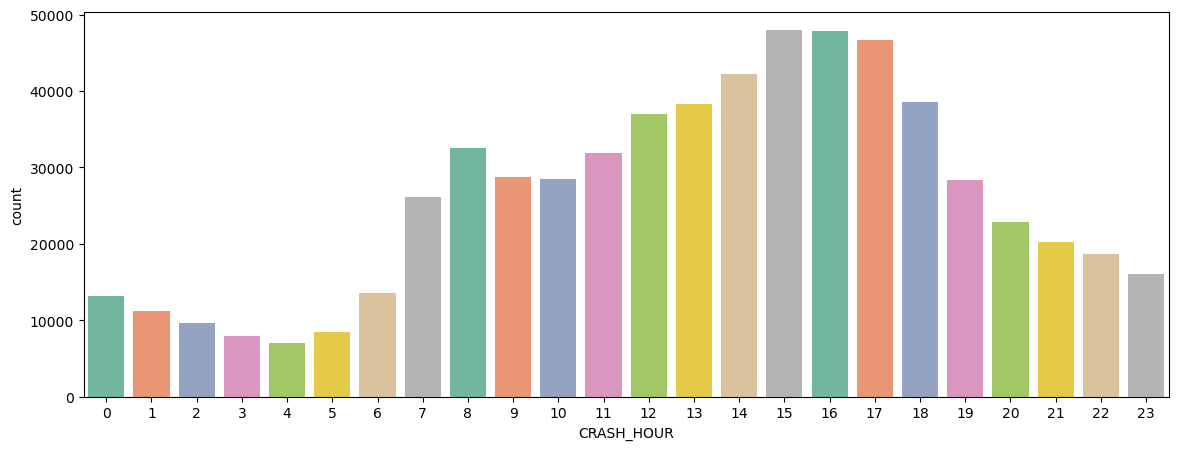

In [28]:
#Faixas de horário que mais ocorrem acidentes. Como em outras metrópoles, a maior parte dos acidentes ocorrem à tarde
plt.figure(figsize = (14,5))
sns.countplot(x=df_clean['CRASH_HOUR'], data=df_clean, palette="Set2")

C:\Users\vilia\AppData\Local\Temp\ipykernel_13360\3050785475.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clean['CRASH_DAY_OF_WEEK'], data=df_clean, palette="Set1")


<Axes: xlabel='CRASH_DAY_OF_WEEK', ylabel='count'>

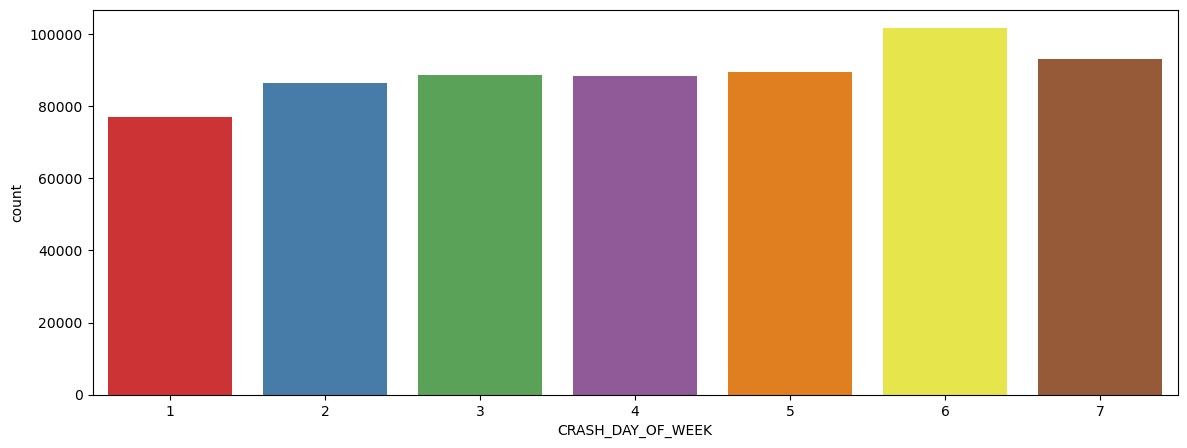

In [29]:
#Quantidade de acidentes por dia da semana. Apresenta equilíbrio entre os dias
plt.figure(figsize = (14,5))
sns.countplot(x=df_clean['CRASH_DAY_OF_WEEK'], data=df_clean, palette="Set1")

In [30]:
Fatalidades = df_clean.loc[df_clean['INJURIES_FATAL'] >= 1]
Fatalidades

,RD_NO,CRASH_DATE,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,ALIGNMENT,ROADWAY_SURFACE_COND,ROAD_DEFECT,REPORT_TYPE,CRASH_TYPE,DAMAGE,DATE_POLICE_NOTIFIED,PRIM_CONTRIBUTORY_CAUSE,SEC_CONTRIBUTORY_CAUSE,STREET_NO,STREET_DIRECTION,STREET_NAME,BEAT_OF_OCCURRENCE,NUM_UNITS,MOST_SEVERE_INJURY,INJURIES_TOTAL,INJURIES_FATAL,INJURIES_INCAPACITATING,INJURIES_NON_INCAPACITATING,INJURIES_REPORTED_NOT_EVIDENT,INJURIES_NO_INDICATION,INJURIES_UNKNOWN,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,LATITUDE,LONGITUDE,LOCATION
534,JC435095,09/16/2019 01:56:00 AM,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,"DARKNESS, LIGHTED ROAD",PEDESTRIAN,ONE-WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,"OVER $1,500",09/16/2019 01:56:00 AM,UNABLE TO DETERMINE,UNABLE TO DETERMINE,19,E,OHIO ST,1834.0,2,FATAL,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1,2,9,41.892374,-87.627243,POINT (-87.627242941998 41.892374041012)
829,JF176347,03/16/2022 07:37:00 PM,35,NO CONTROLS,NO CONTROLS,CLEAR,DARKNESS,PEDESTRIAN,DIVIDED - W/MEDIAN (NOT RAISED),STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,"OVER $1,500",03/16/2022 07:39:00 PM,FAILING TO REDUCE SPEED TO AVOID CRASH,FAILING TO YIELD RIGHT-OF-WAY,10934,S,WESTERN AVE,2212.0,2,FATAL,1.0,1.0,0.0,0.0,0.0,1.0,0.0,19,4,3,41.694578,-87.681392,POINT (-87.681392214993 41.694577925956)
942,JD293557,07/11/2020 06:41:00 AM,25,NO CONTROLS,NO CONTROLS,CLEAR,DAYLIGHT,HEAD ON,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,"OVER $1,500",07/11/2020 06:53:00 AM,IMPROPER LANE USAGE,UNABLE TO DETERMINE,2558,W,PETERSON AVE,2413.0,2,FATAL,4.0,1.0,1.0,2.0,0.0,0.0,0.0,6,7,7,41.990581,-87.694474,POINT (-87.694474132951 41.990580936971)
2500,JF177608,03/17/2022 08:07:00 PM,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,DUSK,PEDESTRIAN,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NOT ON SCENE (DESK REPORT),INJURY AND / OR TOW DUE TO CRASH,"OVER $1,500",03/17/2022 08:08:00 PM,UNABLE TO DETERMINE,UNABLE TO DETERMINE,6000,W,GRAND AVE,2512.0,2,FATAL,1.0,1.0,0.0,0.0,0.0,1.0,0.0,20,5,3,41.920677,-87.775630,POINT (-87.775630269041 41.920676630982)
3521,JA493953,11/01/2017 02:15:00 AM,35,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,"DARKNESS, LIGHTED ROAD",PEDESTRIAN,DIVIDED - W/MEDIAN BARRIER,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,"OVER $1,500",11/01/2017 02:25:00 AM,UNABLE TO DETERMINE,UNABLE TO DETERMINE,8300,S,STONY ISLAND AVE,412.0,2,FATAL,1.0,1.0,0.0,0.0,0.0,1.0,0.0,2,4,11,41.744152,-87.585945,POINT (-87.585945066953 41.744151639042)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
628854,JC298208,06/08/2019 09:22:00 PM,30,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",HEAD ON,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,"OVER $1,500",06/08/2019 09:22:00 PM,UNABLE TO DETERMINE,UNABLE TO DETERMINE,421,N,PULASKI RD,1122.0,2,FATAL,5.0,1.0,4.0,0.0,0.0,0.0,0.0,21,7,6,41.888533,-87.725735,POINT (-87.725735104346 41.888532589795)
629853,JF131548,02/03/2022 06:30:00 AM,30,NO CONTROLS,NO CONTROLS,BLOWING SNOW,DAYLIGHT,SIDESWIPE SAME DIRECTION,DIVIDED - W/MEDIAN (NOT RAISED),STRAIGHT AND LEVEL,SNOW OR SLUSH,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,"OVER $1,500",02/03/2022 06:43:00 AM,PHYSICAL CONDITION OF DRIVER,PHYSICAL CONDITION OF DRIVER,4041,N,CICERO AVE,1722.0,3,FATAL,1.0,1.0,0.0,0.0,0.0,2.0,0.0,6,5,2,41.954683,-87.747191,POINT (-87.747191243946 41.954682570475)
630550,JF210763,04/17/2022 02:54:00 PM,30,STOP SIGN/FLASHER,FUNCTIONING PROPERLY,CLEAR,DAYLIGHT,PEDESTRIAN,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,$500 OR LESS,04/17/2022 02:54:00 PM,FAILING TO YIELD RIGHT-OF-WAY,NOT APPLICABLE,4500,N,HAZEL ST,1914.0,2,FATAL,2.0,1.0,0.0,1.0,0.0,5.0,0.0,1

C:\Users\vilia\AppData\Local\Temp\ipykernel_13360\1566236760.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=Fatalidades['CRASH_DAY_OF_WEEK'], data=Fatalidades, palette="Set3")


<Axes: xlabel='CRASH_DAY_OF_WEEK', ylabel='count'>

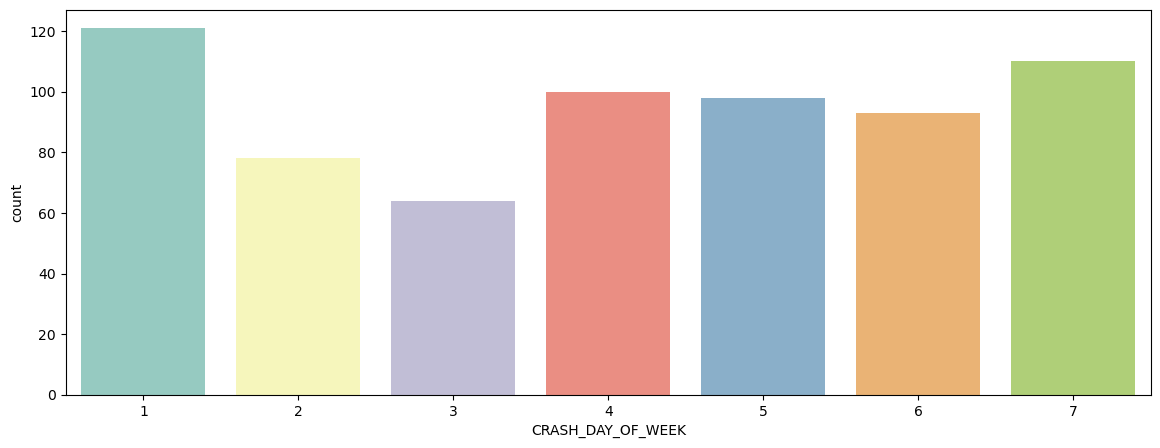

In [31]:
#Dias da semana em que mais ocorrem acidentes com fatalidades. Fim de semana lidera
plt.figure(figsize = (14,5))
sns.countplot(x=Fatalidades['CRASH_DAY_OF_WEEK'], data=Fatalidades, palette="Set3")

In [32]:
df_clean['DAMAGE'].value_counts()

DAMAGE
OVER $1,500      373681
$501 - $1,500    175104
$500 OR LESS      74998
Name: count, dtype: int64

C:\Users\vilia\AppData\Local\Temp\ipykernel_13360\4173557245.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clean['DAMAGE'], data=df_clean, palette="Set1")


<Axes: xlabel='DAMAGE', ylabel='count'>

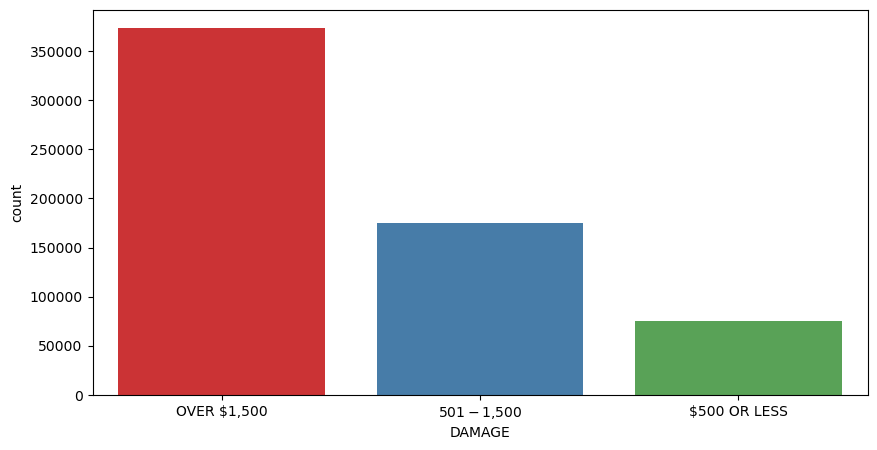

In [33]:
#Valor de dano dos acidentes
plt.figure(figsize = (10,5))
sns.countplot(x=df_clean['DAMAGE'], data=df_clean, palette="Set1")

C:\Users\vilia\AppData\Local\Temp\ipykernel_13360\791623505.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=Fatalidades['CRASH_MONTH'], data=Fatalidades, palette="Set3")


<Axes: xlabel='CRASH_MONTH', ylabel='count'>

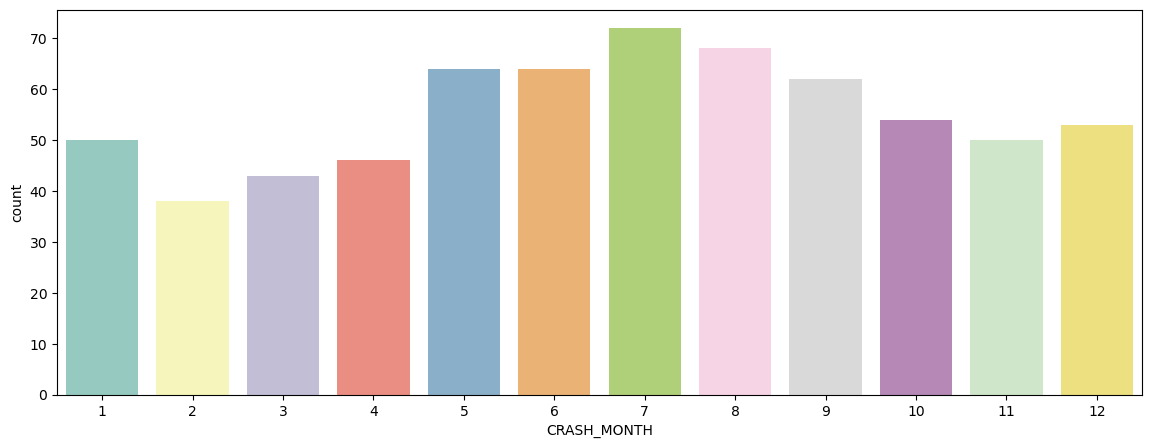

In [34]:
#Quantidade de acidentes com fatalidades por mês. Há uma queda nos meses mais frios
plt.figure(figsize = (14,5))
sns.countplot(x=Fatalidades['CRASH_MONTH'], data=Fatalidades, palette="Set3")

In [35]:
df_clean.head()

,RD_NO,CRASH_DATE,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,ALIGNMENT,ROADWAY_SURFACE_COND,ROAD_DEFECT,REPORT_TYPE,CRASH_TYPE,DAMAGE,DATE_POLICE_NOTIFIED,PRIM_CONTRIBUTORY_CAUSE,SEC_CONTRIBUTORY_CAUSE,STREET_NO,STREET_DIRECTION,STREET_NAME,BEAT_OF_OCCURRENCE,NUM_UNITS,MOST_SEVERE_INJURY,INJURIES_TOTAL,INJURIES_FATAL,INJURIES_INCAPACITATING,INJURIES_NON_INCAPACITATING,INJURIES_REPORTED_NOT_EVIDENT,INJURIES_NO_INDICATION,INJURIES_UNKNOWN,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,LATITUDE,LONGITUDE,LOCATION
1,JD347173,08/27/2020 02:48:00 PM,30,NO CONTROLS,NO CONTROLS,CLEAR,DAYLIGHT,REAR END,DIVIDED - W/MEDIAN (NOT RAISED),STRAIGHT AND LEVEL,WET,UNKNOWN,NOT ON SCENE (DESK REPORT),INJURY AND / OR TOW DUE TO CRASH,"OVER $1,500",08/27/2020 02:49:00 PM,UNABLE TO DETERMINE,UNABLE TO DETERMINE,2605,N,PULASKI RD,2524.0,2,"REPORTED, NOT EVIDENT",1.0,0.0,0.0,0.0,1.0,1.0,0.0,14,5,8,41.928341,-87.726734,POINT (-87.726734064044 41.928340900019)
4,JF244095,05/16/2022 08:29:00 AM,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,DAYLIGHT,REAR END,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NOT ON SCENE (DESK REPORT),NO INJURY / DRIVE AWAY,"$501 - $1,500",05/16/2022 10:00:00 AM,IMPROPER BACKING,UNABLE TO DETERMINE,8147,S,VINCENNES AVE,622.0,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0.0,8,2,5,41.745792,-87.635370,POINT (-87.63536999702 41.745792169991)
5,JF228431,05/03/2022 08:50:00 AM,25,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,RAIN,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,WET,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,"OVER $1,500",05/03/2022 08:51:00 AM,FAILING TO YIELD RIGHT-OF-WAY,DRIVING SKILLS/KNOWLEDGE/EXPERIENCE,5000,W,FOSTER AVE,1623.0,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0.0,8,3,5,41.975384,-87.752959,POINT (-87.752958923026 41.975383528015)
9,JF244267,05/16/2022 10:31:00 AM,30,NO CONTROLS,NO CONTROLS,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,"OVER $1,500",05/16/2022 10:31:00 AM,FAILING TO YIELD RIGHT-OF-WAY,NOT APPLICABLE,2305,W,47TH ST,931.0,2,NONINCAPACITATING INJURY,1.0,0.0,0.0,1.0,0.0,1.0,0.0,10,2,5,41.808321,-87.682241,POINT (-87.68224077098 41.808320646996)
11,JF214106,04/20/2022 05:45:00 PM,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NOT ON SCENE (DESK REPORT),NO INJURY / DRIVE AWAY,"OVER $1,500",04/20/2022 06:42:00 PM,DISREGARDING TRAFFIC SIGNALS,FAILING TO REDUCE SPEED TO AVOID CRASH,1859,N,ELSTON AVE,1433.0,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0.0,17,4,4,41.916381,-87.666190,POINT (-87.666189730021 41.916381427046)


In [39]:
#Verificar se há faixa de horários com mais fatalidades
Fatalidades.head()

,RD_NO,CRASH_DATE,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,ALIGNMENT,ROADWAY_SURFACE_COND,ROAD_DEFECT,REPORT_TYPE,CRASH_TYPE,DAMAGE,DATE_POLICE_NOTIFIED,PRIM_CONTRIBUTORY_CAUSE,SEC_CONTRIBUTORY_CAUSE,STREET_NO,STREET_DIRECTION,STREET_NAME,BEAT_OF_OCCURRENCE,NUM_UNITS,MOST_SEVERE_INJURY,INJURIES_TOTAL,INJURIES_FATAL,INJURIES_INCAPACITATING,INJURIES_NON_INCAPACITATING,INJURIES_REPORTED_NOT_EVIDENT,INJURIES_NO_INDICATION,INJURIES_UNKNOWN,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,LATITUDE,LONGITUDE,LOCATION
534,JC435095,09/16/2019 01:56:00 AM,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,"DARKNESS, LIGHTED ROAD",PEDESTRIAN,ONE-WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,"OVER $1,500",09/16/2019 01:56:00 AM,UNABLE TO DETERMINE,UNABLE TO DETERMINE,19,E,OHIO ST,1834.0,2,FATAL,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1,2,9,41.892374,-87.627243,POINT (-87.627242941998 41.892374041012)
829,JF176347,03/16/2022 07:37:00 PM,35,NO CONTROLS,NO CONTROLS,CLEAR,DARKNESS,PEDESTRIAN,DIVIDED - W/MEDIAN (NOT RAISED),STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,"OVER $1,500",03/16/2022 07:39:00 PM,FAILING TO REDUCE SPEED TO AVOID CRASH,FAILING TO YIELD RIGHT-OF-WAY,10934,S,WESTERN AVE,2212.0,2,FATAL,1.0,1.0,0.0,0.0,0.0,1.0,0.0,19,4,3,41.694578,-87.681392,POINT (-87.681392214993 41.694577925956)
942,JD293557,07/11/2020 06:41:00 AM,25,NO CONTROLS,NO CONTROLS,CLEAR,DAYLIGHT,HEAD ON,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,"OVER $1,500",07/11/2020 06:53:00 AM,IMPROPER LANE USAGE,UNABLE TO DETERMINE,2558,W,PETERSON AVE,2413.0,2,FATAL,4.0,1.0,1.0,2.0,0.0,0.0,0.0,6,7,7,41.990581,-87.694474,POINT (-87.694474132951 41.990580936971)
2500,JF177608,03/17/2022 08:07:00 PM,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,DUSK,PEDESTRIAN,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NOT ON SCENE (DESK REPORT),INJURY AND / OR TOW DUE TO CRASH,"OVER $1,500",03/17/2022 08:08:00 PM,UNABLE TO DETERMINE,UNABLE TO DETERMINE,6000,W,GRAND AVE,2512.0,2,FATAL,1.0,1.0,0.0,0.0,0.0,1.0,0.0,20,5,3,41.920677,-87.775630,POINT (-87.775630269041 41.920676630982)
3521,JA493953,11/01/2017 02:15:00 AM,35,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,"DARKNESS, LIGHTED ROAD",PEDESTRIAN,DIVIDED - W/MEDIAN BARRIER,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,"OVER $1,500",11/01/2017 02:25:00 AM,UNABLE TO DETERMINE,UNABLE TO DETERMINE,8300,S,STONY ISLAND AVE,412.0,2,FATAL,1.0,1.0,0.0,0.0,0.0,1.0,0.0,2,4,11,41.744152,-87.585945,POINT (-87.585945066953 41.744151639042)


In [41]:
hora_fatalidades = duckdb.query("""SELECT CRASH_HOUR, sum(INJURIES_FATAL) FROM Fatalidades GROUP BY CRASH_HOUR ORDER BY 2 DESC""")
hora_fatalidades

┌────────────┬─────────────────────┐
│ CRASH_HOUR │ sum(INJURIES_FATAL) │
│   int64    │       double        │
├────────────┼─────────────────────┤
│         23 │                52.0 │
│          1 │                50.0 │
│         19 │                47.0 │
│          3 │                47.0 │
│          2 │                42.0 │
│         21 │                42.0 │
│         20 │                41.0 │
│         22 │                38.0 │
│         12 │                33.0 │
│          4 │                32.0 │
│          · │                  ·  │
│          · │                  ·  │
│          · │                  ·  │
│         17 │                25.0 │
│          5 │                23.0 │
│         11 │                23.0 │
│          9 │                20.0 │
│         10 │                20.0 │
│         13 │                19.0 │
│          8 │                19.0 │
│         16 │                17.0 │
│          6 │                12.0 │
│          7 │                10.0 │
└

C:\Users\vilia\AppData\Local\Temp\ipykernel_13360\3720959753.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=Fatalidades['CRASH_HOUR'], data=Fatalidades, palette="autumn_r")


<Axes: xlabel='CRASH_HOUR', ylabel='count'>

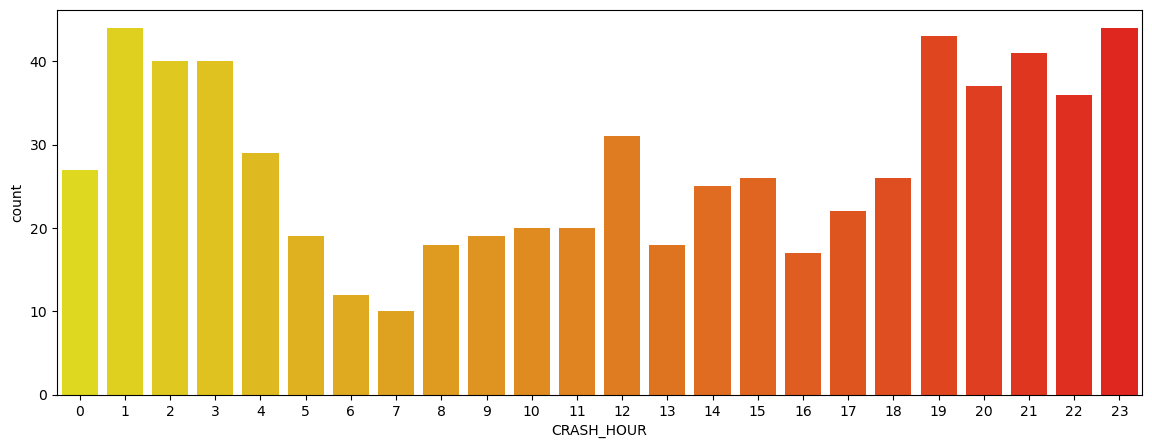

In [47]:
#Fatalidades por paixa de horário. Horário comercial, com exceção do meio dia, são as faixas com os menores números de fatalidade
plt.figure(figsize = (14,5))
sns.countplot(x=Fatalidades['CRASH_HOUR'], data=Fatalidades, palette="autumn_r")

In [ ]:
#Lista top 10 quais limites